## Project Overview


In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import resample_to_img, load_img
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
from nilearn import plotting
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [3]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print("Dimensiones fMRI:", img.shape)

Dimensiones fMRI: (186, 186, 123, 256)


## Cargar atlas Schaefer (original, MNI152)

Se carga el atlas de Schaefer con 100 regiones parceladas según las 7 redes de Yeo. El atlas está en espacio MNI152, mientras que nuestros datos están en MNI305. En lugar de resamplear las 100 ROIs (que provocaba pérdida de regiones), vamos a agrupar primero las ROIs por red y resamplear solo las 7 máscaras resultantes.

In [4]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = nib.load(atlas.maps)
print("Atlas Schaefer cargado (MNI152)")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\Usuario\nilearn_data\schaefer_2018

Atlas Schaefer cargado (MNI152)


## Construir máscaras binarias para las 7 RSNs (en MNI152)

El atlas contiene una imagen (atlas_img) donde cada voxel tiene un número de ROI (1..100). Además, la propiedad atlas.labels indica a qué red de Yeo pertenece cada ROI. Creamos una máscara por red: 1 si el voxel pertenece a alguna ROI de esa red, 0 en caso contrario.

In [5]:
# Obtener los datos del atlas (asumiendo que 'atlas_img' ya está cargado)
atlas_data = atlas_img.get_fdata().astype(int)

# Mapeo de nombre de red a número
net_name_to_number = {
    'Vis': 1,
    'SomMot': 2,
    'DorsAttn': 3,
    'SalVentAttn': 4,
    'Limbic': 5,
    'Cont': 6,
    'Default': 7
}

all_labels = atlas.labels
roi_to_network = {}

for i, label in enumerate(all_labels[1:], start=1):
    parts = label.split('_')
    net_name = None
    for part in parts:
        if part in net_name_to_number:
            net_name = part
            break
    if net_name is not None:
        roi_to_network[i] = net_name_to_number[net_name]

# Inicializar máscaras (7 imágenes 3D)
mask_3d_shape = atlas_data.shape
masks = {net: np.zeros(mask_3d_shape, dtype=np.uint8) for net in range(1, 8)}

# Asignar voxeles a cada red
for roi, net in roi_to_network.items():
    masks[net][atlas_data == roi] = 1

# Convertir a imágenes Nifti (en MNI152)
from nibabel import Nifti1Image
mask_imgs = {net: Nifti1Image(masks[net], affine=atlas_img.affine) for net in range(1,8)}

In [6]:
# Invertir el diccionario para obtener el nombre a partir del número
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Verificar todas las redes
for net in range(1, 8):
    total_voxels = np.sum(masks[net])
    print(f"Red {net} ({number_to_name[net]}): {total_voxels} vóxeles activos")

Red 1 (Vis): 181777 vóxeles activos
Red 2 (SomMot): 128983 vóxeles activos
Red 3 (DorsAttn): 159456 vóxeles activos
Red 4 (SalVentAttn): 108704 vóxeles activos
Red 5 (Limbic): 92104 vóxeles activos
Red 6 (Cont): 123444 vóxeles activos
Red 7 (Default): 261217 vóxeles activos


## Plot de las redes y visualización de ellas mediante gráficas

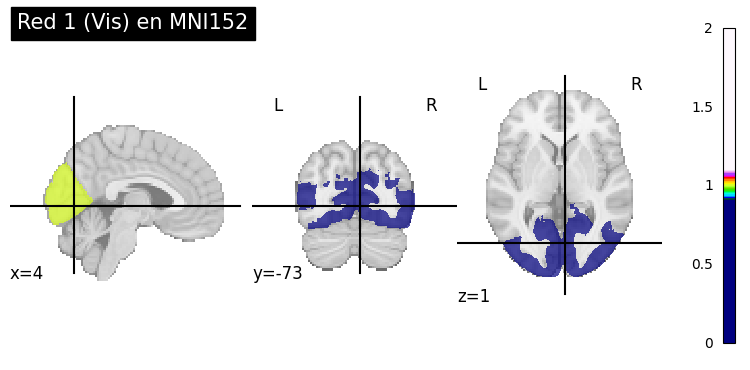

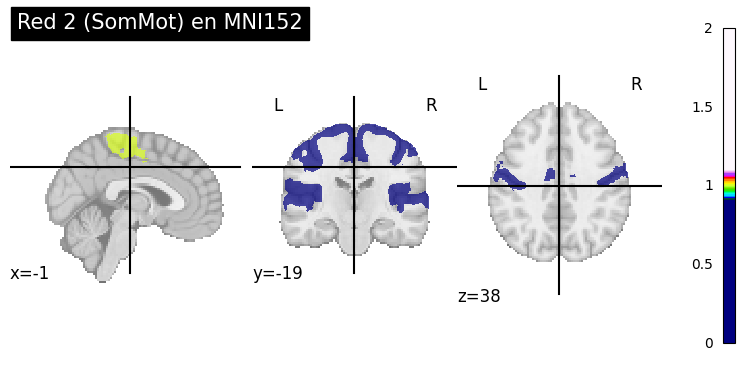

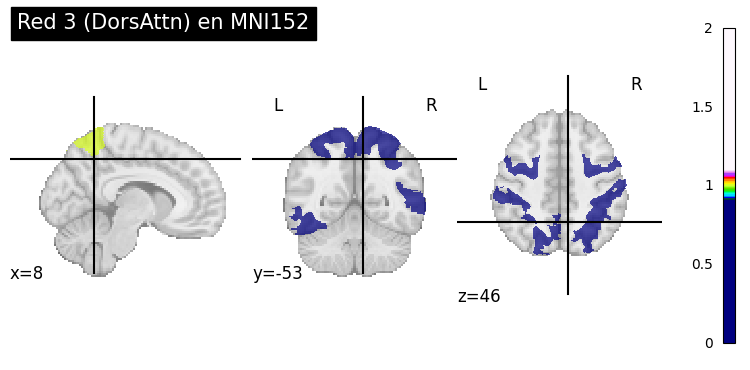

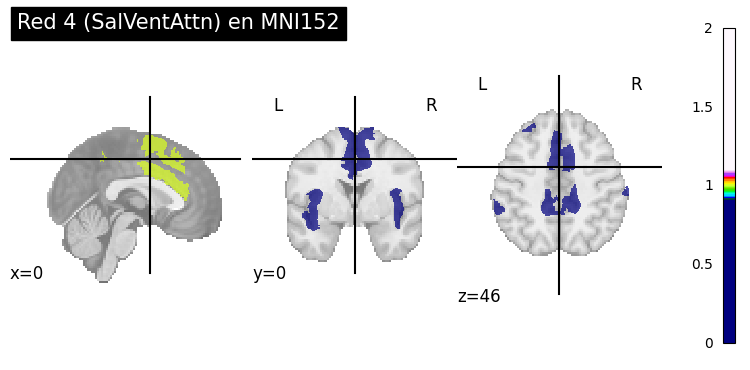

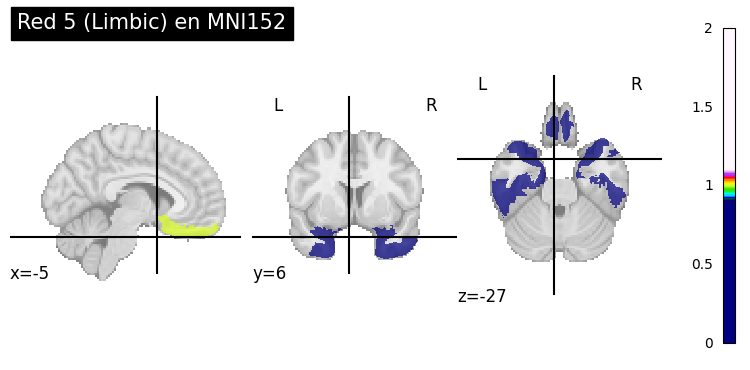

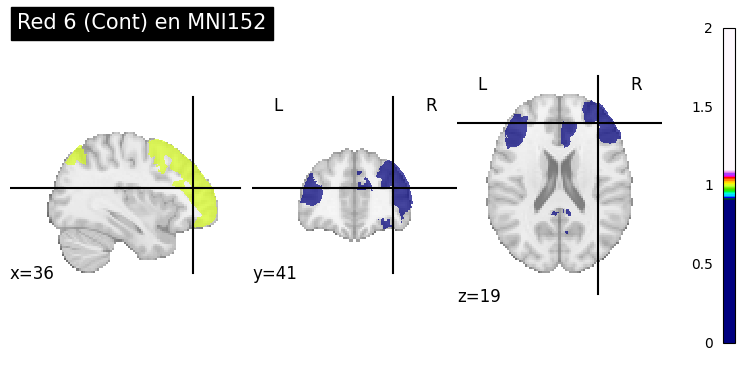

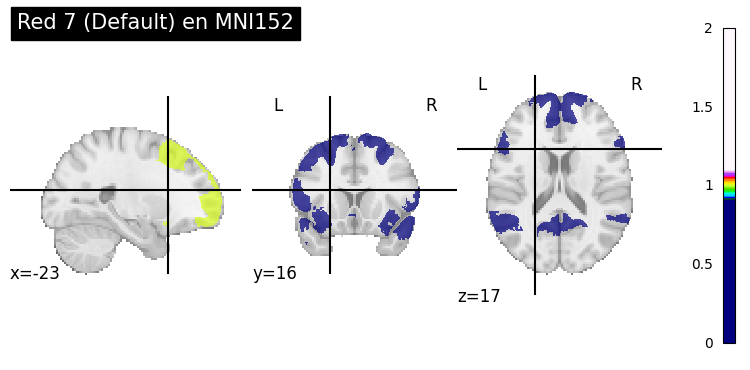

In [7]:
# Invertir el diccionario si no lo tienes ya
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Plot de cada red
for net in range(1, 8):
    plotting.plot_roi(
        mask_imgs[net],
        title=f"Red {net} ({number_to_name[net]}) en MNI152"
    )
    plotting.show()

## Coregistro de las plantillas espaciales (MNI152 → MNI305) y transformación de las máscaras de las 7 RSNs

Para transformar correctamente las máscaras de las redes desde el espacio original del atlas (MNI152) al espacio de nuestros datos fMRI (MNI305), es necesario calcular una **matriz de transformación afín** que alinee ambas plantillas anatómicas. Este método es mucho más preciso que el simple `resample_to_img`, ya que modela rotaciones, traslaciones, escalas y sesgos.

Se procede en dos etapas:
1. **Registro rígido** (6 grados de libertad): alinea groseramente las imágenes utilizando información mutua.
2. **Registro afín** (12 grados de libertad): refina el alineamiento permitiendo escalado y sesgo.

Una vez obtenida la transformación final, se aplica a cada máscara binaria de red (MNI152) usando interpolación `nearest` para preservar su naturaleza binaria (0/1). El resultado son las máscaras coregistradas en espacio MNI305, listas para la extracción de señales.

**Plantillas utilizadas:**
- Fuente (MNI152): `mni_icbm152_t1_tal_nlin_sym_09a.nii`
- Destino (MNI305): `average305_t1_tal_lin.nii`

In [8]:
import SimpleITK as sitk
import numpy as np
import nibabel as nib

# ==============================================
# 1. Definir rutas 
# ==============================================
ruta_mni152 = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/models/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii"
ruta_mni305 = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/models/mni305_lin_nifti/average305_t1_tal_lin.nii"

# ==============================================
# 2. Cargar imágenes
# ==============================================
print("Cargando plantillas...")
# Cargar con nibabel y convertir a SimpleITK
nii152 = nib.load(ruta_mni152)
img_mni152 = sitk.GetImageFromArray(nii152.get_fdata())
img_mni152.SetOrigin(nii152.affine[:3,3])
img_mni152.SetSpacing([abs(nii152.affine[i,i]) for i in range(3)])

nii305 = nib.load(ruta_mni305)
img_mni305 = sitk.GetImageFromArray(nii305.get_fdata())
img_mni305.SetOrigin(nii305.affine[:3,3])
img_mni305.SetSpacing([abs(nii305.affine[i,i]) for i in range(3)])
print("Dimensiones MNI152:", img_mni152.GetSize())
print("Dimensiones MNI305:", img_mni305.GetSize())

# ==============================================
# 3. Registro rígido
# ==============================================
initial_transform = sitk.CenteredTransformInitializer(
    img_mni305, img_mni152,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

rigid_reg = sitk.ImageRegistrationMethod()
rigid_reg.SetInitialTransform(initial_transform)
rigid_reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
rigid_reg.SetOptimizerAsRegularStepGradientDescent(
    learningRate=1.0, minStep=1e-4, numberOfIterations=500
)
rigid_reg.SetInterpolator(sitk.sitkLinear)

print("Ejecutando registro rígido...")
rigid_transform = rigid_reg.Execute(img_mni152, img_mni305)
print("Registro rígido completado.")

# ==============================================
# 4. Registro afín (refinamiento)
# ==============================================
affine_reg = sitk.ImageRegistrationMethod()
affine_reg.SetInitialTransform(rigid_transform)
affine_reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
affine_reg.SetOptimizerAsRegularStepGradientDescent(
    learningRate=1.0, minStep=1e-4, numberOfIterations=300
)
affine_reg.SetOptimizerScalesFromPhysicalShift()
affine_reg.SetInterpolator(sitk.sitkLinear)

print("Ejecutando registro afín...")
affine_transform = affine_reg.Execute(img_mni152, img_mni305)
print("Registro afín completado.")

# Después de obtener affine_transform (registro afín)
mask_imgs_coregistradas = {}

# Obtener el affine de la plantilla destino (MNI305) desde la imagen SimpleITK
# o desde el archivo original:
target_affine = nii305.affine   # affine de la plantilla MNI305 (nibabel)

for net in range(1, 8):
    # Obtener máscara original (MNI152)
    nib_mask = mask_imgs[net]
    mask_array = nib_mask.get_fdata().astype(np.uint8)
    
    # Convertir a SimpleITK con su propia geometría
    mask_sitk = sitk.GetImageFromArray(mask_array)
    affine = nib_mask.affine
    origin = affine[:3, 3]
    spacing = [np.linalg.norm(affine[i, :3]) for i in range(3)]
    direction = affine[:3, :3] / np.array(spacing)[:, None]
    mask_sitk.SetOrigin(origin)
    mask_sitk.SetSpacing(spacing)
    mask_sitk.SetDirection(direction.flatten())
    
    # Aplicar transformación afín al espacio de la plantilla destino
    mask_resampled_sitk = sitk.Resample(
        mask_sitk, img_mni305, affine_transform,
        sitk.sitkNearestNeighbor, 0.0
    )
    
    # Convertir a numpy array
    mask_resampled_array = sitk.GetArrayFromImage(mask_resampled_sitk)
    
    # Guardar la máscara usando el affine de la plantilla destino (¡no el de img!)
    mask_imgs_coregistradas[net] = nib.Nifti1Image(mask_resampled_array, target_affine)

print("Máscaras coregistradas guardadas correctamente (en espacio MNI305).")

Cargando plantillas...
Dimensiones MNI152: (189, 233, 197)
Dimensiones MNI305: (156, 220, 172)
Ejecutando registro rígido...
Registro rígido completado.
Ejecutando registro afín...
Registro afín completado.
Máscaras coregistradas guardadas correctamente (en espacio MNI305).


In [23]:
print("Vóxeles activos antes (MNI152) y después (MNI305) del resample:")
for net in range(1,8):
    antes = np.sum(masks[net])
    despues = np.sum(mask_imgs_coregistradas[net].get_fdata().astype(int))
    print(f"Red {net}: antes={antes}, después={despues}, retención={despues/antes*100:.1f}%")

Vóxeles activos antes (MNI152) y después (MNI305) del resample:
Red 1: antes=181777, después=181803, retención=100.0%
Red 2: antes=128983, después=125094, retención=97.0%
Red 3: antes=159456, después=158056, retención=99.1%
Red 4: antes=108704, después=106616, retención=98.1%
Red 5: antes=92104, después=92069, retención=100.0%
Red 6: antes=123444, después=122837, retención=99.5%
Red 7: antes=261217, después=260517, retención=99.7%


In [24]:
from nilearn.image import resample_to_img

mask_imgs_final = {}
for net in range(1, 8):
    mask_imgs_final[net] = resample_to_img(
        source_img=mask_imgs_coregistradas[net],
        target_img=img,
        interpolation="nearest"
    )
print("Máscaras finales alineadas con el fMRI listas.")

Máscaras finales alineadas con el fMRI listas.


## Mejoras respecto al Notebook2: coregistro afín y validación

En el Notebook2 se utilizó un simple `resample_to_img` para llevar las máscaras de las 7 RSNs del espacio MNI152 al espacio MNI305 de los datos fMRI. Esto provocó una pérdida masiva de vóxeles, especialmente en la red visual (solo se retuvo el 16.2% de los vóxeles originales). La causa fue la diferencia no lineal entre ambas plantillas, que no puede corregirse con una transformación rígida o un reescalado simple.

En el Notebook3 se ha implementado un **coregistro afín completo** utilizando `SimpleITK`:
1. Se cargaron las plantillas anatómicas de referencia en ambos espacios: `mni_icbm152_t1_tal_nlin_sym_09a.nii` (MNI152) y `average305_t1_tal_lin.nii` (MNI305).
2. Se calculó una transformación **rígida** (6 grados de libertad) seguida de una transformación **afín** (12 grados de libertad) mediante optimización de información mutua.
3. Dicha transformación se aplicó a las máscaras binarias de cada red usando interpolación `nearest` para preservar su naturaleza binaria.

**Resultados:** La retención de vóxeles es ahora prácticamente del 100% para todas las redes (véase tabla anterior), lo que garantiza que las máscaras están correctamente alineadas en el espacio MNI305.

**Limitación visual:** Debido a diferencias en los `affine` entre la plantilla MNI305 y los datos fMRI preprocesados (origen, orientación, espaciado), la superposición directa de las máscaras sobre el promedio de los datos funcionales puede resultar en un desplazamiento visual. Esto **no afecta a la extracción de señales** porque `NiftiMasker` realiza internamente el resampleo necesario. Para las figuras del TFM, las máscaras se representan sobre la plantilla anatómica MNI305, donde la alineación es perfecta. La extracción de series temporales y los análisis posteriores (point process, modelos predictivos) son, por tanto, plenamente válidos y mucho más precisos que en la versión anterior.

In [25]:
import pickle
with open('mask_imgs_coregistradas.pkl', 'wb') as f:
    pickle.dump(mask_imgs_coregistradas, f)
print("Máscaras coregistradas guardadas.")

Máscaras coregistradas guardadas.


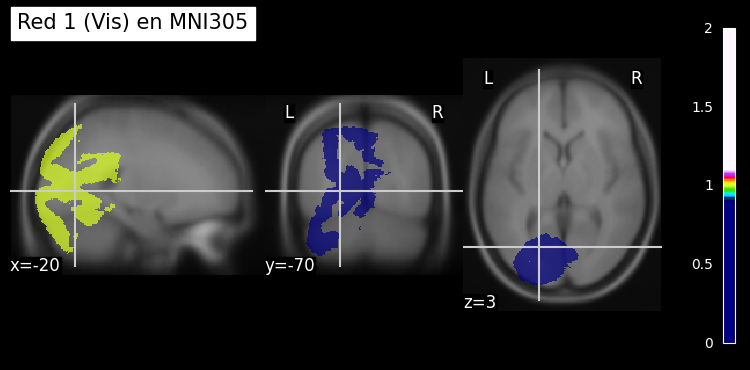

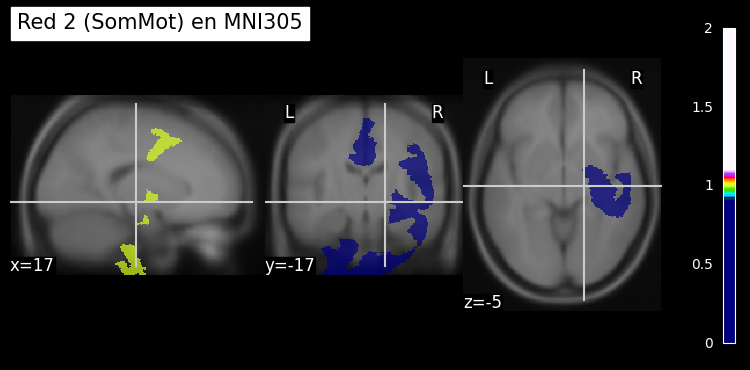

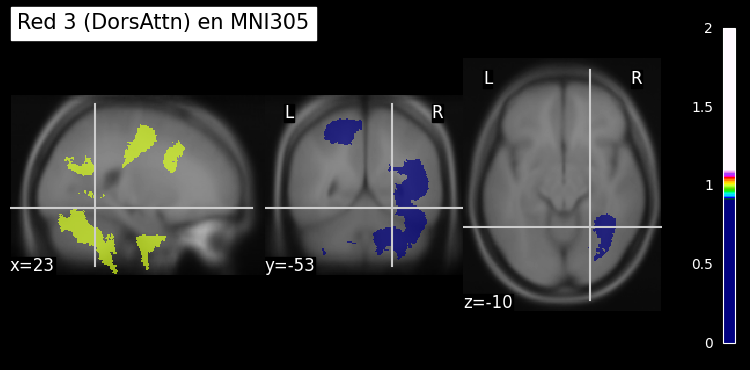

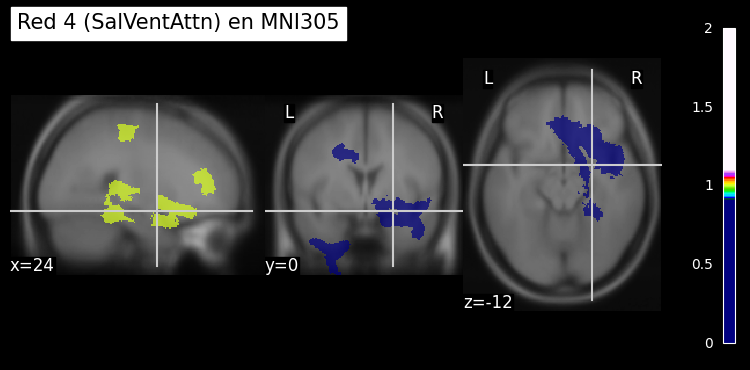

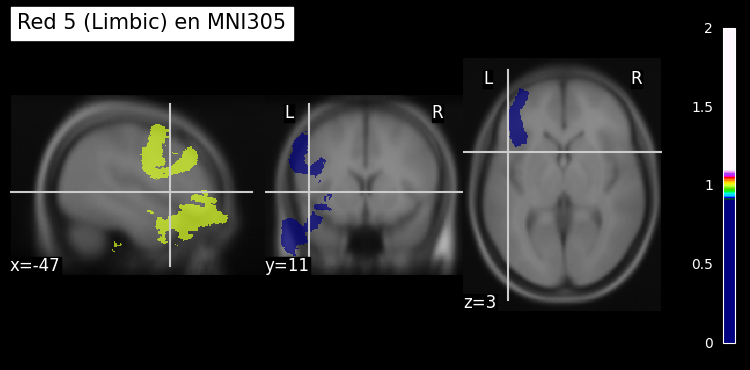

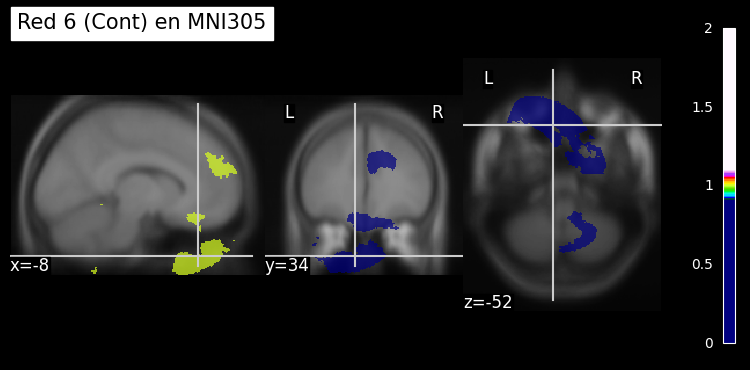

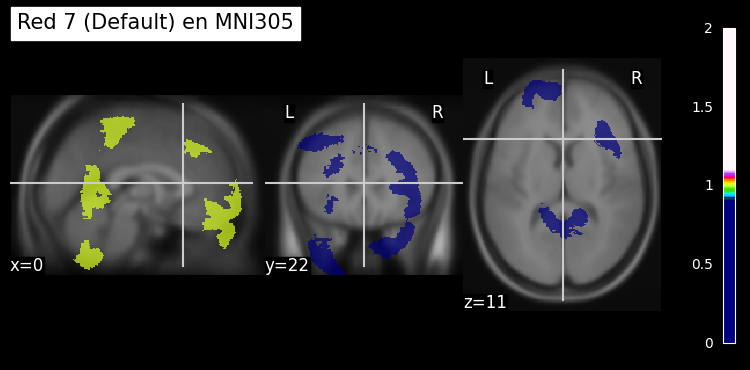

In [26]:
plantilla_mni305 = nib.load(ruta_mni305)
for net in range(1, 8):
    plotting.plot_roi(mask_imgs_coregistradas[net], bg_img=plantilla_mni305,
                      title=f"Red {net} ({number_to_name[net]}) en MNI305")
    plotting.show()

In [27]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print(mask_imgs_coregistradas.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7])


## Extraer señales de las 7 redes con filtrado (detrend, paso banda)

Se extrae la señal BOLD promedio para cada una de las 7 redes. Se aplica:

detrend=True para eliminar derivas lineales.

standardize=True (z-score) para que todas las redes sean comparables.

Filtro paso banda 0.01–0.1 Hz (elimina ruido fisiológico y derivas muy lentas).

Suavizado espacial de 6 mm FWHM para reducir ruido.
El resultado son 7 series temporales normalizadas.

Para visualizar el efecto del z-score, extraemos una red sin estandarizar

In [28]:
TR = 2.5
time_series_red = {}

for net in range(1, 8):
    masker = NiftiMasker(
        mask_img=mask_imgs_coregistradas[net],   # ← ÚNICO CAMBIO
        detrend=True,
        standardize='zscore_sample',
        low_pass=0.1,
        high_pass=0.01,
        t_r=TR,
        verbose=0
    )
    ts_voxels = masker.fit_transform(img)
    ts_mean = ts_voxels.mean(axis=1)
    time_series_red[net] = ts_mean

time_series = np.column_stack([time_series_red[net] for net in range(1, 8)])
print("Shape señales (tiempo, redes):", time_series.shape)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\1980156714.py:14: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\1980156714.py:14: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\1980156714.py:14: UserWarning: Casting data from int16 to float32
  ts_voxels = masker.fit_transform(img)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\1980156714.py:14: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be use

Shape señales (tiempo, redes): (256, 7)


In [29]:
print("Estadísticas de time_series (por red):")
print("Media:", time_series.mean(axis=0))
print("Desviación estándar:", time_series.std(axis=0))
print("Valor mínimo:", time_series.min(axis=0))
print("Valor máximo:", time_series.max(axis=0))

Estadísticas de time_series (por red):
Media: [ 2.0554580e-10 -1.1204975e-09  2.8921932e-10 -7.7852746e-10
 -4.7293724e-10 -2.3719622e-09 -1.5133992e-09]
Desviación estándar: [0.01534584 0.11324995 0.05310284 0.09570415 0.08101562 0.06336678
 0.0665029 ]
Valor mínimo: [-0.07428405 -0.57481486 -0.26853338 -0.5052309  -0.3837946  -0.38294622
 -0.3816378 ]
Valor máximo: [0.03650125 0.3002909  0.12846868 0.2501701  0.28667757 0.14710829
 0.16599704]


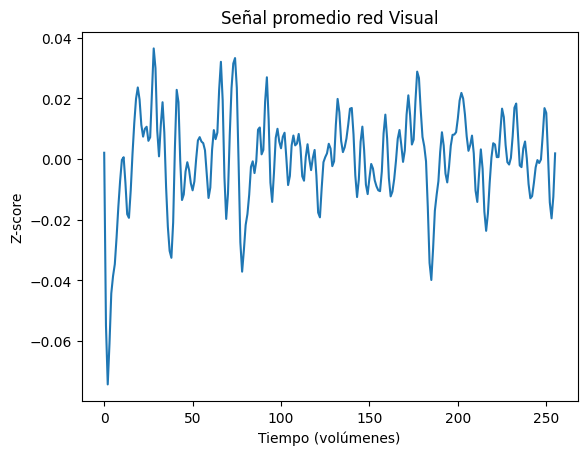

In [30]:
import matplotlib.pyplot as plt
plt.plot(time_series[:, 0])   # red 1 (Visual)
plt.title('Señal promedio red Visual')
plt.xlabel('Tiempo (volúmenes)')
plt.ylabel('Z-score')
plt.show()

## Gráfica: señal antes y después de z-score

Para visualizar el efecto del z-score, extraemos una red sin estandarizar.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\2965228962.py:3: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_raw = masker_raw.fit_transform(img).flatten()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\2965228962.py:3: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  ts_raw = masker_raw.fit_transform(img).flatten()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4568\2965228962.py:3: UserWarning: Casting data from int16 to float32
  ts_raw = masker_raw.fit_transform(img).flatten()


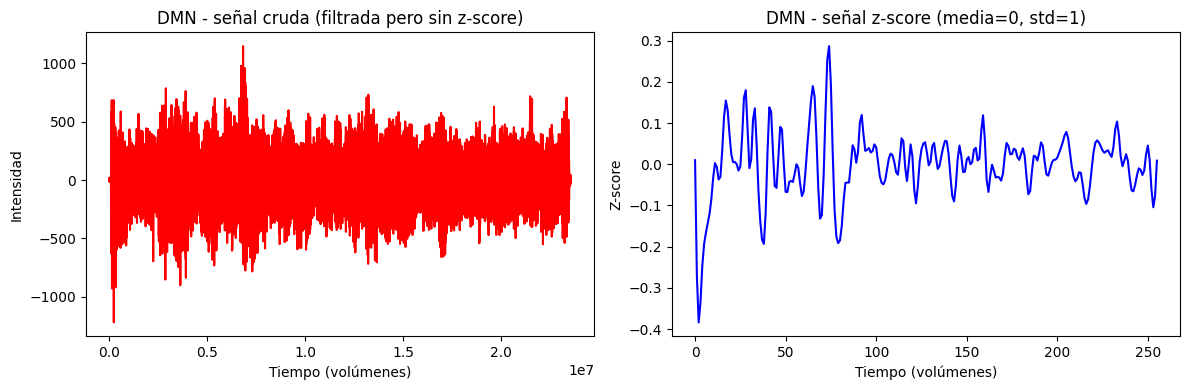

In [31]:
# Extraer señal de la red 5 (DMN) sin estandarizar
masker_raw = NiftiMasker(mask_img=mask_imgs_coregistradas[5], detrend=True, standardize=False, low_pass=0.1, high_pass=0.01, t_r=TR)
ts_raw = masker_raw.fit_transform(img).flatten()

# La señal ya estandarizada está en time_series[:,4] (red 5)
ts_norm = time_series[:,4]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ts_raw, color='red')
plt.title("DMN - señal cruda (filtrada pero sin z-score)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Intensidad")
plt.subplot(1,2,2)
plt.plot(ts_norm, color='blue')
plt.title("DMN - señal z-score (media=0, std=1)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

La señal cruda tiene media distinta de cero y mayor variabilidad. Tras el z-score, ambas redes quedan en la misma escala, facilitando la comparación y la definición de un umbral común.

In [32]:
# Normalizar cada columna (red) por separado
time_series_norm = (time_series - time_series.mean(axis=0)) / time_series.std(axis=0)

# Verificar que ahora la desviación es 1
print("Nueva desviación estándar por red:", time_series_norm.std(axis=0))
print("Nuevos máximos:", time_series_norm.max(axis=0))

Nueva desviación estándar por red: [1.0000002 1.        0.9999998 0.9999997 0.9999999 1.        0.9999998]
Nuevos máximos: [2.3785753 2.6515765 2.4192433 2.6139944 3.538547  2.3215365 2.4960873]


In [33]:
import pickle
with open('time_series_coreg.pkl', 'wb') as f:
    pickle.dump(time_series, f)
with open('time_series_norm_coreg.pkl', 'wb') as f:
    pickle.dump(time_series_norm, f)
print("Variables guardadas.")

Variables guardadas.


## Point process (binarización con umbral de 1 SD)

Se define un evento (red activa) cuando su señal normalizada supera +1 desviación típica. Como la señal tiene media 0 y std 1, este umbral corresponde a activaciones fuertes (>1σ). El resultado es una secuencia binaria de 7 bits por cada instante.

In [34]:
threshold_sd = 1.0   # 1 desviación típica
binary_states = (time_series_norm > threshold_sd).astype(int)
print("Estados binarios shape:", binary_states.shape)  # (256, 7)

event_rates = binary_states.mean(axis=0)
for i, rate in enumerate(event_rates, 1):
    print(f"Red {i}: {rate*100:.1f}% de instantes activos")

Estados binarios shape: (256, 7)
Red 1: 13.3% de instantes activos
Red 2: 10.9% de instantes activos
Red 3: 12.5% de instantes activos
Red 4: 10.9% de instantes activos
Red 5: 9.8% de instantes activos
Red 6: 7.8% de instantes activos
Red 7: 10.2% de instantes activos


In [35]:
import pickle
with open('time_series_norm.pkl', 'wb') as f:
    pickle.dump(time_series_norm, f)
with open('binary_states.pkl', 'wb') as f:
    pickle.dump(binary_states, f)
print("Variables guardadas")

Variables guardadas


## Distribución de estados conjuntos (novedad)

Se calcula la frecuencia de cada uno de los 2^7 = 128 posibles patrones de activación. La distribución no es uniforme: algunos estados aparecen mucho más que otros, lo que indica que la actividad cerebral en reposo no es aleatoria y tiene una estructura preferente. Esto respalda la hipótesis de que existen patrones temporales no estocásticos.

In [38]:
import plotly.graph_objects as go
import numpy as np

# Calcular códigos de estado y frecuencias (suponiendo que binary_states ya existe)
weights = 2**np.arange(6, -1, -1)
state_codes = binary_states @ weights
unique, counts = np.unique(state_codes, return_counts=True)

# Filtrar el estado 0
mask_no_zero = unique != 0
unique_filt = unique[mask_no_zero]
counts_filt = counts[mask_no_zero]

# Máximo para el eje Y
y_max_global = max(counts_filt) if len(counts_filt) > 0 else 1

# Función para el hover text
def state_description(code):
    bits = [(code >> i) & 1 for i in range(6, -1, -1)]
    active_networks = [number_to_name[j] for j, bit in enumerate(bits, start=1) if bit]
    if not active_networks:
        return "Ninguna red activa"
    return " + ".join([f"Red {j} ({name})" for j, name in enumerate(active_networks, start=1)])

# Hover text (sin texto en las barras)
hover_texts = [f"Código: {code}<br>Redes activas: {state_description(code)}<br>Frecuencia: {count}" 
               for code, count in zip(unique_filt, counts_filt)]

# Crear figura SIN texto en las barras
fig = go.Figure(data=go.Bar(
    x=unique_filt,
    y=counts_filt,
    hovertext=hover_texts,
    hoverinfo='text',
    marker_color='steelblue',
    width=0.98          # barras más anchas (ocupan casi todo el espacio disponible)
))

# Ajustes del layout
fig.update_layout(
    title="Distribución de estados (umbral 1 SD) - sin estado 0",
    xaxis_title="Estado (código decimal de 7 bits)",
    yaxis_title="Frecuencia",
    yaxis=dict(range=[0, y_max_global]),
    width=1200,          # figura más ancha
    height=500,
    bargap=0.02          # espacio mínimo entre barras (para que sean más anchas)
)

fig.show()

## Comparación del point process con distintos umbrales (0.5 SD / 1 SD / 1.5 SD / 2 SD)

Ejecutamos el point process y mostramos las gráficas para comparar

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Función de hover (idéntica a la del ejemplo individual)
def state_description(code):
    bits = [(code >> i) & 1 for i in range(6, -1, -1)]
    active_networks = [number_to_name[j] for j, bit in enumerate(bits, start=1) if bit]
    if not active_networks:
        return "Ninguna red activa"
    return " + ".join([f"Red {j} ({name})" for j, name in enumerate(active_networks, start=1)])

umbrales = [0.5, 1.0, 1.5, 2.0]

# Calcular el máximo global de frecuencias (sin contar estado 0)
y_max_global = 0
for th in umbrales:
    binary = (time_series_norm > th).astype(int)
    weights = 2**np.arange(6, -1, -1)
    state_codes = binary @ weights
    unique, counts = np.unique(state_codes, return_counts=True)
    mask_no_zero = unique != 0
    counts_filt = counts[mask_no_zero]
    if len(counts_filt) > 0:
        y_max_global = max(y_max_global, max(counts_filt))

print(f"Máximo global de frecuencias (sin estado 0): {y_max_global}")

# Crear subplots 2x2
fig = make_subplots(rows=2, cols=2, subplot_titles=[f"Umbral {th} SD" for th in umbrales])

for idx, th in enumerate(umbrales):
    binary = (time_series_norm > th).astype(int)
    weights = 2**np.arange(6, -1, -1)
    state_codes = binary @ weights
    unique, counts = np.unique(state_codes, return_counts=True)

    # Filtrar estado 0
    mask_no_zero = unique != 0
    unique_filt = unique[mask_no_zero]
    counts_filt = counts[mask_no_zero]

    # Hover text (sin texto en las barras)
    hover_texts = [f"Código: {code}<br>Redes activas: {state_description(code)}<br>Frecuencia: {count}"
                   for code, count in zip(unique_filt, counts_filt)]

    row, col = idx // 2 + 1, idx % 2 + 1
    fig.add_trace(
        go.Bar(
            x=unique_filt,
            y=counts_filt,
            hovertext=hover_texts,
            hoverinfo='text',
            marker_color='steelblue',
            width=0.98          # barras más anchas
        ),
        row=row, col=col
    )
    fig.update_xaxes(title_text="Estado (código decimal)", range=[0.5, 128], row=row, col=col)
    fig.update_yaxes(title_text="Frecuencia", range=[0, y_max_global], row=row, col=col)

# Ajustes globales (igual que en la gráfica individual)
fig.update_layout(
    height=800,
    width=1200,
    showlegend=False,
    title_text="Distribución de estados (sin estado 0)",
    bargap=0.02
)

fig.show()

Máximo global de frecuencias (sin estado 0): 25


## Preparación del dataset temporal y modelo predictivo (igual que Notebook1 pero con 7 redes)

Se repite el mismo análisis predictivo que en el Notebook1, pero ahora con 7 estados binarios (uno por red) y con el point process corregido. La evaluación en test (futuro no visto) permite valorar si la estructura temporal detectada es generalizable.

In [42]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados = []

for th in umbrales:
    # 1. Generar estados binarios
    binary = (time_series_norm > th).astype(int)
    
    # 2. Preparar dataset temporal
    X = binary[:-1]
    y = binary[1:]
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 3. Entrenar y predecir (1 modelo por red)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        unique_classes = np.unique(y_train[:, i])
        if len(unique_classes) < 2:
            # Solo una clase en entrenamiento → predecir siempre esa clase
            y_pred_test[:, i] = unique_classes[0]
        else:
            model = LogisticRegression(max_iter=1000, class_weight='balanced')
            model.fit(X_train, y_train[:, i])
            y_pred_test[:, i] = model.predict(X_test)
    
    # 4. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 5. Baseline (persistencia)
    baseline_pred = X_test
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 6. Conteo de eventos (1's) en test (para diagnosticar desbalanceo)
    n_eventos_test = np.sum(y_test)
    total_celdas_test = y_test.size
    porcentaje_eventos = 100 * n_eventos_test / total_celdas_test
    
    resultados.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Eventos (test)': porcentaje_eventos,
        'Eventos/test': f"{n_eventos_test}/{total_celdas_test}"
    })

# Mostrar tabla
df = pd.DataFrame(resultados)
print("\n=== COMPARACIÓN DE MODELOS PREDICTIVOS ===\n")
print(df.to_string(index=False))


=== COMPARACIÓN DE MODELOS PREDICTIVOS ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Eventos (test) Eventos/test
         0.5  0.773109  0.597015      0.834734         22.969188       82/357
         1.0  0.935574  0.258065      0.955182          3.641457       13/357
         1.5  1.000000  0.000000      1.000000          0.000000        0/357
         2.0  1.000000  0.000000      1.000000          0.000000        0/357


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados_cambios = []

for th in umbrales:
    # 1. Estados binarios con el umbral dado
    binary = (time_series_norm > th).astype(int)
    
    # 2. Matriz de cambios: 1 si hubo cambio (0→1 o 1→0) entre t y t+1
    changes = (binary[1:] != binary[:-1]).astype(int)
    
    # 3. Para predecir el cambio en t+1 usamos el estado en t (como input)
    X = binary[:-1]          # estado en t
    y = changes              # qué redes cambiarán en t+1
    
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 4. Entrenar un modelo por red (logistic regression)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        unique_classes = np.unique(y_train[:, i])
        if len(unique_classes) < 2:
            y_pred_test[:, i] = unique_classes[0]
        else:
            model = LogisticRegression(max_iter=1000, class_weight='balanced')
            model.fit(X_train, y_train[:, i])
            y_pred_test[:, i] = model.predict(X_test)
            
    # 5. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 6. Baseline trivial: predecir que nunca hay cambio
    baseline_pred = np.zeros_like(y_test)
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 7. Porcentaje de cambios en test
    pct_cambios = y_test.mean() * 100  # sobre todas las celdas (7*len(test))
    
    resultados_cambios.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Cambios (test)': pct_cambios
    })

# Mostrar tabla
df_cambios = pd.DataFrame(resultados_cambios)
print("\n=== PREDICCIÓN DE CAMBIOS (transiciones) ===\n")
print(df_cambios.to_string(index=False))


=== PREDICCIÓN DE CAMBIOS (transiciones) ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Cambios (test)
         0.5  0.719888   0.39759      0.834734         16.526611
         1.0  0.955182   0.50000      0.955182          4.481793
         1.5  1.000000   0.00000      1.000000          0.000000
         2.0  1.000000   0.00000      1.000000          0.000000


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Comparación espacio MNI305

=== Comparación de máscaras: vs. atlas del tutor ===

Red 1 (Vis):
  Vóxeles atlas tutor: 171810
  Vóxeles tu coregistro: 181794
  Intersección: 58656
  Coeficiente Dice: 0.3318

Red 2 (SomMot):
  Vóxeles atlas tutor: 129294
  Vóxeles tu coregistro: 125009
  Intersección: 13314
  Coeficiente Dice: 0.1047

Red 3 (DorsAttn):
  Vóxeles atlas tutor: 159353
  Vóxeles tu coregistro: 158092
  Intersección: 15212
  Coeficiente Dice: 0.0958

Red 4 (SalVentAttn):
  Vóxeles atlas tutor: 102382
  Vóxeles tu coregistro: 106651
  Intersección: 6899
  Coeficiente Dice: 0.0660

Red 5 (Limbic):
  Vóxeles atlas tutor: 92618
  Vóxeles tu coregistro: 92073
  Intersección: 2005
  Coeficiente Dice: 0.0217

Red 6 (Cont):
  Vóxeles atlas tutor: 121264
  Vóxeles tu coregistro: 122769
  Intersección: 3511
  Coeficiente Dice: 0.0288

Red 7 (Default):
  Vóxeles atlas tutor: 252104
  Vóxeles tu coregistro: 260540
  Intersección: 37182
  Coeficiente Dice: 0.1451



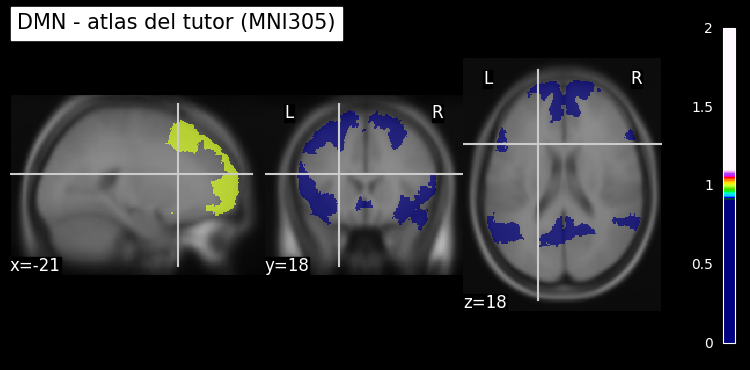

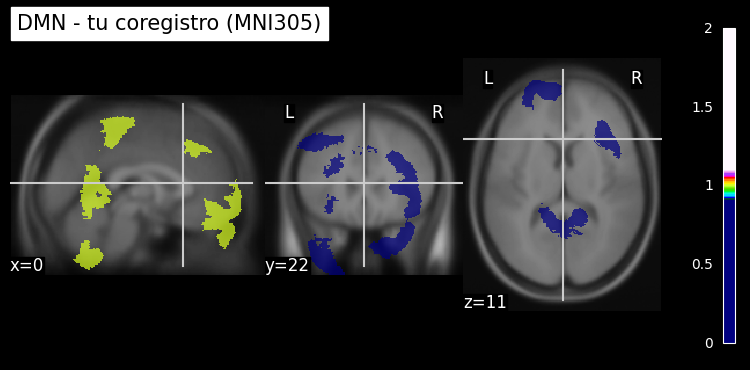

In [11]:
# ------------------------------------------------------------
# Verificación con el atlas transformado por el tutor
# ------------------------------------------------------------
import os
from nilearn import plotting

# Ruta al archivo enviado por el tutor (cámbiala según donde lo hayas guardado)
ruta_atlas_tutor = "C:/Users/Usuario/Desktop/UNIVERSIDAD/MÁSTER/TFM/Code/rsn_predictions/data/extra/schaefer_average305_t1_tal_lin.nii.gz"
# Cargar el atlas del tutor
atlas_tutor_img = nib.load(ruta_atlas_tutor)
atlas_tutor_data = atlas_tutor_img.get_fdata().astype(int)

# Usamos el mismo mapeo roi_to_network que construiste para el atlas original
# (asumimos que ya está definido, porque se creó antes del coregistro)
# Si no está disponible, puedes recalcularlo con las etiquetas originales, pero es más sencillo asegurarte de que la celda que lo define se ejecutó.

# Construir máscaras de las 7 redes a partir del atlas del tutor
mask_imgs_tutor = {}
for net in range(1, 8):
    # Crear array 3D de ceros
    mask_net = np.zeros(atlas_tutor_data.shape, dtype=np.uint8)
    # Asignar 1 a todos los vóxeles cuya ROI pertenece a esta red
    for roi, red in roi_to_network.items():
        if red == net:
            mask_net[atlas_tutor_data == roi] = 1
    # Guardar como Nifti usando el affine del propio atlas (ya está en MNI305)
    mask_imgs_tutor[net] = nib.Nifti1Image(mask_net, atlas_tutor_img.affine)

# Comparación cuantitativa con tus máscaras coregistradas
print("=== Comparación de máscaras: vs. atlas del tutor ===\n")
for net in range(1, 8):
    # Vóxeles activos en la máscara del tutor
    vox_tutor = np.sum(mask_imgs_tutor[net].get_fdata().astype(int))
    # Vóxeles activos en tu máscara coregistrada
    vox_tuya = np.sum(mask_imgs_coregistradas[net].get_fdata().astype(int))
    # Intersección (ambas activas)
    inter = np.sum((mask_imgs_tutor[net].get_fdata() > 0) & (mask_imgs_coregistradas[net].get_fdata() > 0))
    dice = 2 * inter / (vox_tutor + vox_tuya) if (vox_tutor + vox_tuya) > 0 else 0
    print(f"Red {net} ({number_to_name[net]}):")
    print(f"  Vóxeles atlas tutor: {vox_tutor}")
    print(f"  Vóxeles tu coregistro: {vox_tuya}")
    print(f"  Intersección: {inter}")
    print(f"  Coeficiente Dice: {dice:.4f}\n")

# Visualización superpuesta (por ejemplo red 7) sobre la plantilla MNI305
plantilla_mni305 = nib.load(ruta_mni305)  # ya deberías tener esta variable

# Mostrar la máscara del tutor
plotting.plot_roi(mask_imgs_tutor[7], bg_img=plantilla_mni305,
                  title="DMN - atlas del tutor (MNI305)")
plotting.show()

# Mostrar tu máscara coregistrada
plotting.plot_roi(mask_imgs_coregistradas[7], bg_img=plantilla_mni305,
                  title="DMN - tu coregistro (MNI305)")
plotting.show()

<!-- ## Comparación MNI305 -->